In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
airbnb_NYC = pd.read_csv('AB_NYC_2019.csv')
airbnb_NYC

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [21]:
airbnb_NYC.shape

(48895, 16)

In [22]:
airbnb_NYC.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [23]:
airbnb_NYC['last_review'] = pd.to_datetime(airbnb_NYC['last_review'])
airbnb_NYC.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,int64


In [24]:
airbnb_NYC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48895 non-null  int64         
 1   name                            48879 non-null  object        
 2   host_id                         48895 non-null  int64         
 3   host_name                       48874 non-null  object        
 4   neighbourhood_group             48895 non-null  object        
 5   neighbourhood                   48895 non-null  object        
 6   latitude                        48895 non-null  float64       
 7   longitude                       48895 non-null  float64       
 8   room_type                       48895 non-null  object        
 9   price                           48895 non-null  int64         
 10  minimum_nights                  48895 non-null  int64         
 11  nu

In [25]:
airbnb_NYC.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,2018-10-04 01:47:23.910099456,1.373221,7.143982,112.781327
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,2011-03-28 00:00:00,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,2018-07-08 00:00:00,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,2019-05-19 00:00:00,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,2019-06-23 00:00:00,2.020000,2.000000,227.000000
max,3.648724e+07,NaN,2.743213e+08,NaN,NaN,NaN,40.913060,-73.712990,NaN,10000.000000,1250.000000,629.000000,2019-07-08 00:00:00,58.500000,327.000000,365.000000


In [26]:
airbnb_NYC.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [29]:
airbnb_NYC['name'].fillna('Unknown', inplace=True)
airbnb_NYC['host_name'].fillna('Unknown', inplace=True)

/tmp/ipykernel_238/1499402464.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  airbnb_NYC['name'].fillna('Unknown', inplace=True)
/tmp/ipykernel_238/1499402464.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [30]:
airbnb_NYC['reviews_per_month'].fillna(0, inplace=True)

/tmp/ipykernel_238/3031065721.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  airbnb_NYC['reviews_per_month'].fillna(0, inplace=True)


In [31]:
airbnb_NYC.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [32]:
airbnb_NYC.duplicated().sum()

np.int64(0)

In [33]:
airbnb_NYC['room_type'].value_counts()

,count
room_type,
Entire home/apt,25409
Private room,22326
Shared room,1160


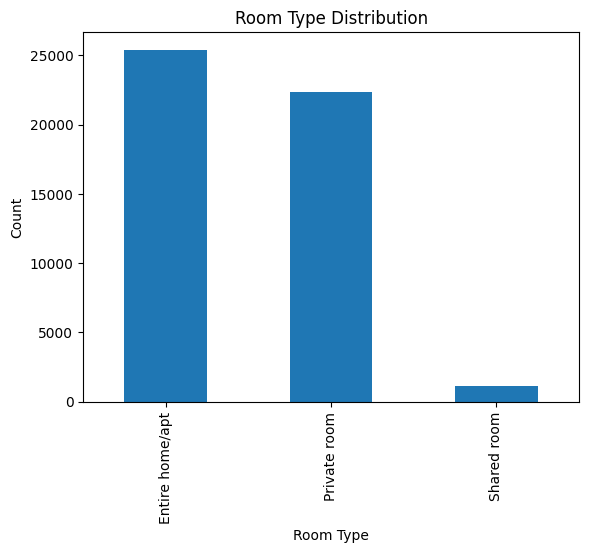

In [34]:
airbnb_NYC['room_type'].value_counts().plot(kind='bar')
plt.title('Room Type Distribution')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

In [37]:
airbnb_NYC['neighbourhood_group'].value_counts()

,count
neighbourhood_group,
Manhattan,21661
Brooklyn,20104
Queens,5666
Bronx,1091
Staten Island,373


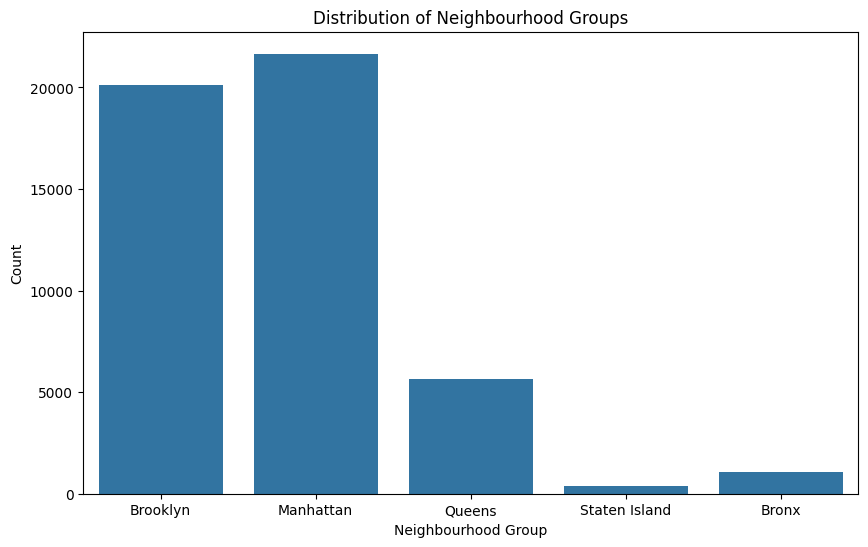

In [36]:
plt.figure(figsize=(10, 6))
sns.countplot(data=airbnb_NYC, x='neighbourhood_group')
plt.title('Distribution of Neighbourhood Groups')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Count')
plt.show()

In [73]:
airbnb_NYC['price'].value_counts()

,count
price,
100,2051
150,2047
50,1534
60,1458
200,1401
...,...
930,1
920,1
4100,1


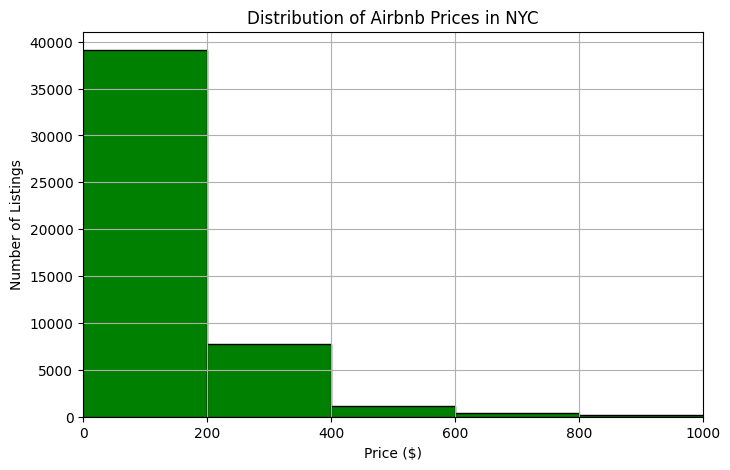

In [58]:
plt.figure(figsize=(8,5))
airbnb_NYC['price'].hist(bins=50, color='green', edgecolor='black')
plt.title("Distribution of Airbnb Prices in NYC")
plt.xlabel("Price ($)")
plt.ylabel('Number of Listings')
plt.xlim(0, 1000)  # limit extreme outliers for clarity
plt.show()

In [55]:
airbnb_NYC['number_of_reviews'].value_counts()

,count
number_of_reviews,
0,10052
1,5244
2,3465
3,2520
4,1994
...,...
372,1
299,1
436,1


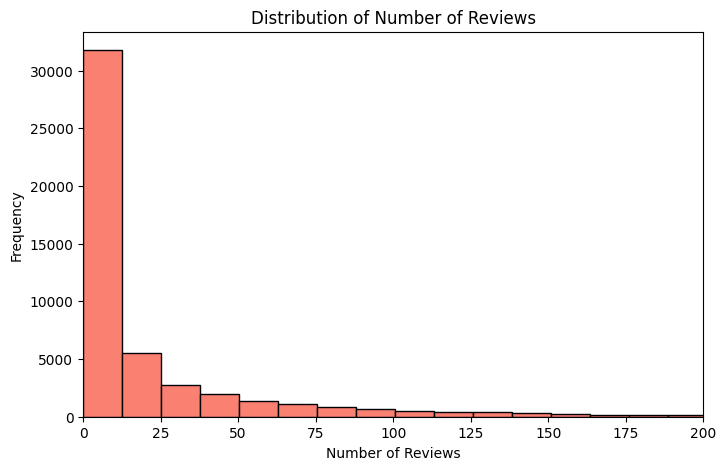

In [54]:
plt.figure(figsize=(8,5))
plt.hist(airbnb_NYC['number_of_reviews'], bins=50, color='salmon', edgecolor='black')
plt.title("Distribution of Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.xlim(0, 200)  # limit extreme outliers
plt.show()

In [74]:
airbnb_NYC['availability_365'].value_counts()

,count
availability_365,
0,17533
365,1295
364,491
1,408
89,361
...,...
195,26
183,24
196,24


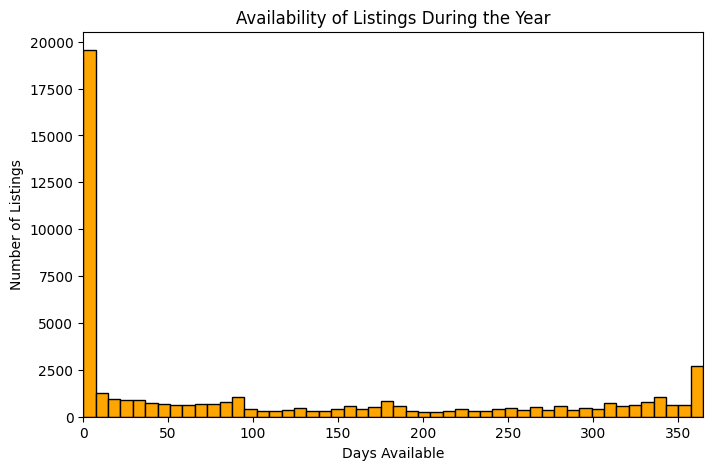

In [60]:
plt.figure(figsize=(8,5))
plt.hist(airbnb_NYC['availability_365'], bins=50, color='orange', edgecolor='black')
plt.title("Availability of Listings During the Year")
plt.xlabel("Days Available")
plt.ylabel("Number of Listings")
plt.xlim(0, 365)  # limit extreme outliers
plt.show()

In [76]:
airbnb_NYC['minimum_nights'].value_counts().sort_index()

,count
minimum_nights,
1,12720
2,11696
3,7999
4,3303
5,3034
...,...
480,1
500,5
999,3


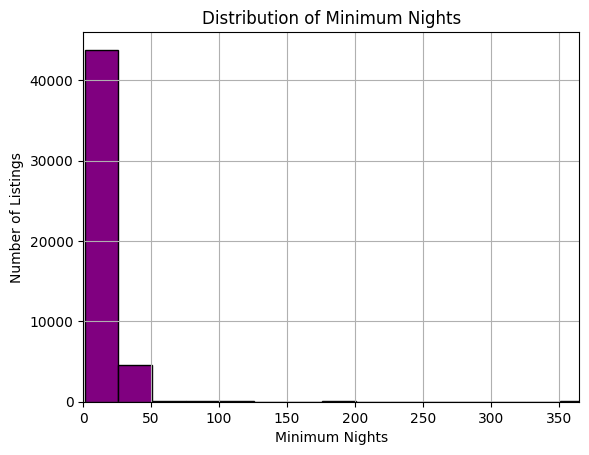

In [72]:
airbnb_NYC['minimum_nights'].hist(bins=50, color='purple', edgecolor='black')
plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Number of Listings")
plt.xlim(0, 365)  # limit extreme outliers
plt.show()

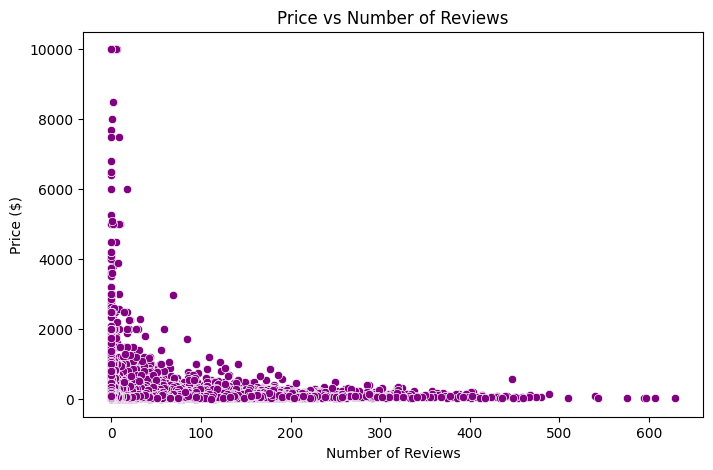

In [68]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=airbnb_NYC, x='number_of_reviews', y='price', color='purple')
plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price ($)")
plt.show()

<Figure size 800x500 with 0 Axes>

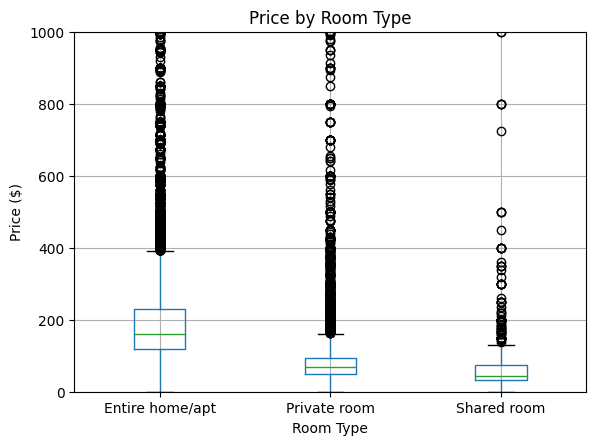

In [64]:
plt.figure(figsize=(8,5))
airbnb_NYC.boxplot(column='price', by='room_type')
plt.title("Price by Room Type")
plt.suptitle("")  # removes automatic 'Boxplot grouped by' title
plt.xlabel("Room Type")
plt.ylabel("Price ($)")
plt.ylim(0, 1000)  # ignore extreme outliers
plt.show()

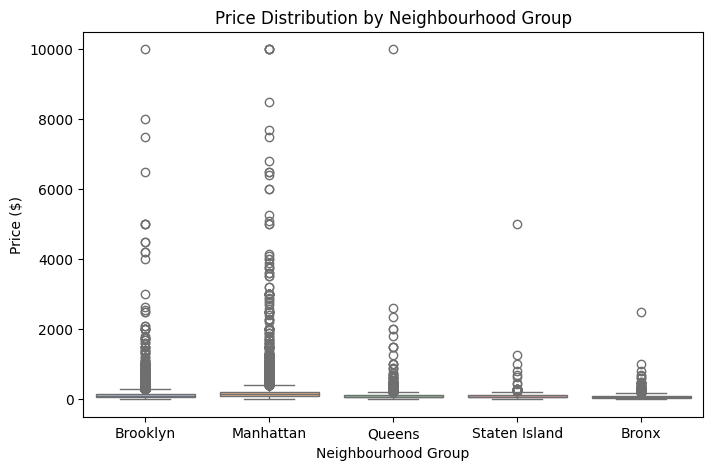

In [66]:
plt.figure(figsize=(8,5))
sns.boxplot(x='neighbourhood_group', y='price', data=airbnb_NYC, hue='neighbourhood_group', palette='pastel')
plt.title("Price Distribution by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Price ($)")
plt.show()